In [10]:
# importaciones
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

In [2]:
data_loan = pd.read_csv("data_loan_clean.csv")

C:\Users\dfgar\AppData\Local\Temp\ipykernel_8696\2178364311.py:1: DtypeWarning: Columns (0: desc, 1: verification_status_joint) have mixed types. Specify dtype option on import or set low_memory=False.
  data_loan = pd.read_csv("data_loan_clean.csv")


In [3]:
print(data_loan["loan_status"].value_counts())

loan_status
Current                                                601779
Fully Paid                                             207723
Charged Off                                             45248
Late (31-120 days)                                      11591
Issued                                                   8460
In Grace Period                                          6253
Late (16-30 days)                                        2357
Does not meet the credit policy. Status:Fully Paid       1988
Default                                                  1219
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [6]:
columnas_seleccionadas = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "term",
    "int_rate",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "initial_list_status",
    "collections_12_mths_ex_med",
    "mths_since_last_major_derog",
    "application_type",
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "emp_title_cat",
]

In [4]:
# ── 1. Transformar loan_status → target binario ────────────────────

status_map = {
    # ── 0 = No default ────────────────────────────────────────────
    "Fully Paid":                                          0,
    "Does not meet the credit policy. Status:Fully Paid":  0,

    # ── 1 = Default ───────────────────────────────────────────────
    "Charged Off":                                         1,
    "Default":                                             1,
    "Late (31-120 days)":                                  1,
    "Late (16-30 days)":                                   1,
    "In Grace Period":                                     1,
    "Does not meet the credit policy. Status:Charged Off": 1,

    # ── Excluir — no tienen resultado definitivo ───────────────────
    # "Current"  → préstamo activo, no sabemos si pagará
    # "Issued"   → recién emitido, sin historial
}

# Filtrar solo filas con resultado claro
data_modelo = data_loan[
    data_loan["loan_status"].isin(status_map.keys())
].copy()

data_modelo["default"] = data_modelo["loan_status"].map(status_map)

# Verificar
print(f"Filas originales:  {len(data_loan):,}")
print(f"Filas para modelo: {len(data_modelo):,}")
print(f"Excluidas:         {len(data_loan) - len(data_modelo):,}  "
      f"(Current + Issued)")

print(f"\nDistribución target:")
print(data_modelo["default"].value_counts())
print(data_modelo["default"].value_counts(normalize=True).mul(100).round(2))

Filas originales:  887,379
Filas para modelo: 277,140
Excluidas:         610,239  (Current + Issued)

Distribución target:
default
0    209711
1     67429
Name: count, dtype: int64
default
0    75.67
1    24.33
Name: proportion, dtype: float64


In [7]:
# ── 2. Separar X e y ───────────────────────────────────────────────
X = data_modelo[columnas_seleccionadas]
y = data_modelo["default"]

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")


Shape X: (277140, 31)
Shape y: (277140,)


In [11]:
# ── 3. Train / Test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Default en train: {y_train.mean()*100:.2f}%")
print(f"Default en test:  {y_test.mean()*100:.2f}%")



Train: (221712, 31) | Test: (55428, 31)
Default en train: 24.33%
Default en test:  24.33%


In [12]:
# ── 4. Imputar NaN con mediana ─────────────────────────────────────
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=columnas_seleccionadas
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=columnas_seleccionadas
)

print(f"\nNaN restantes en X_train: {X_train.isnull().sum().sum()}")



NaN restantes en X_train: 0


In [13]:
# ── 5. Escalar variables ───────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [14]:
# ── 6. Entrenar modelo ─────────────────────────────────────────────
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train_scaled, y_train)
print("\nModelo entrenado ✓")

c:\Users\dfgar\Documents\Unal\RNA y ALGO. BIOINSP\Trabajo 2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Modelo entrenado ✓


In [15]:
# ── 7. Predicciones ────────────────────────────────────────────────
y_pred = modelo.predict(X_test_scaled)
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

In [17]:
# ── 8. Métricas ────────────────────────────────────────────────────
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred,
                             target_names=["No Default (0)", "Default (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


── Classification Report ──────────────────────────────────
                precision    recall  f1-score   support

No Default (0)       0.85      0.66      0.74     41942
   Default (1)       0.37      0.64      0.47     13486

      accuracy                           0.65     55428
     macro avg       0.61      0.65      0.61     55428
  weighted avg       0.73      0.65      0.67     55428

ROC-AUC: 0.7027


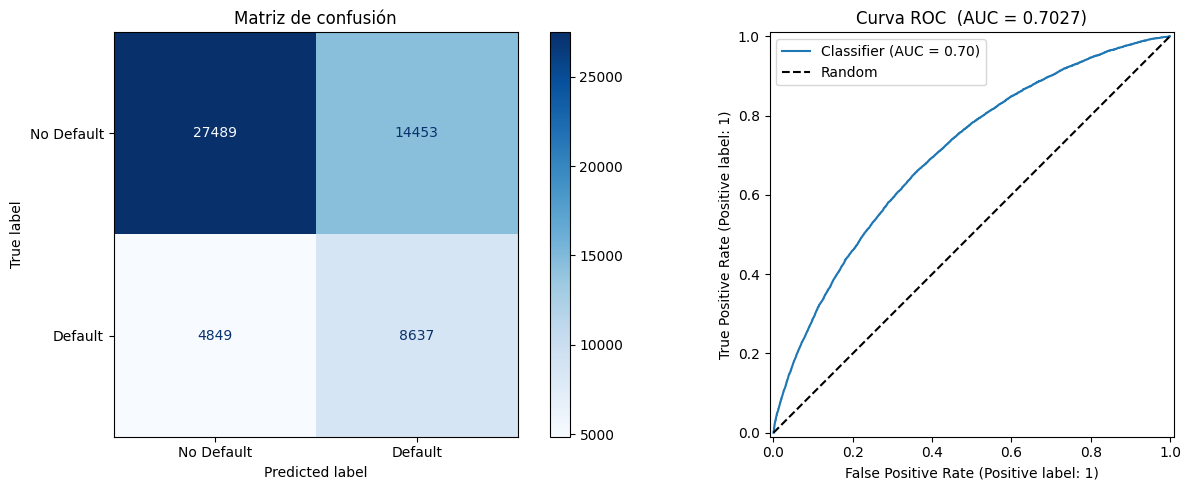

In [21]:
# ── 9. Visualizaciones ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"Curva ROC  (AUC = {roc_auc_score(y_test, y_prob):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].legend()

plt.tight_layout()
plt.show()


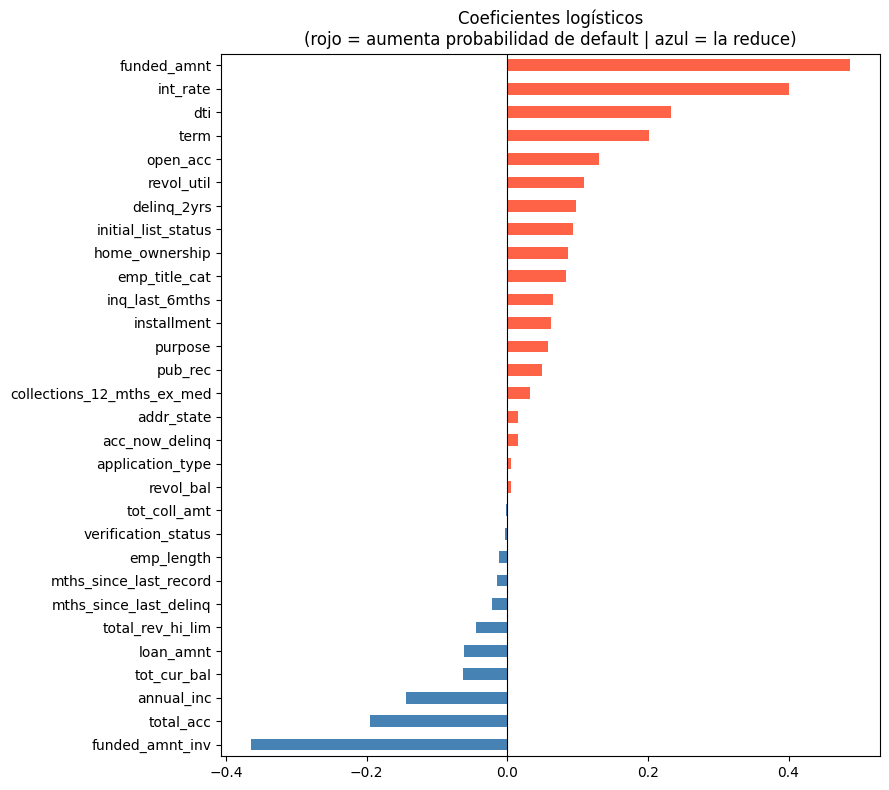


Top 10 variables que MÁS aumentan default:
funded_amnt            0.487542
int_rate               0.400554
dti                    0.233325
term                   0.201099
open_acc               0.130009
revol_util             0.108960
delinq_2yrs            0.097650
initial_list_status    0.093399
home_ownership         0.086112
emp_title_cat          0.083340

Top 10 variables que MÁS reducen default:
verification_status      -0.003014
emp_length               -0.012040
mths_since_last_record   -0.014998
mths_since_last_delinq   -0.022212
total_rev_hi_lim         -0.045050
loan_amnt                -0.061517
tot_cur_bal              -0.063576
annual_inc               -0.143445
total_acc                -0.195664
funded_amnt_inv          -0.363978


In [22]:
# ── 10. Coeficientes ───────────────────────────────────────────────
coeficientes = pd.Series(
    modelo.coef_[0],
    index=columnas_seleccionadas
).sort_values(ascending=False)

# Top 15 positivos y negativos
top_n = 15
top_coefs = pd.concat([
    coeficientes.head(top_n),
    coeficientes.tail(top_n)
]).sort_values()

colores = ["steelblue" if v < 0 else "tomato" for v in top_coefs]

top_coefs.plot(kind="barh", figsize=(9, 8), color=colores)
plt.title("Coeficientes logísticos\n"
          "(rojo = aumenta probabilidad de default | "
          "azul = la reduce)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 variables que MÁS aumentan default:")
print(coeficientes.head(10).to_string())

print("\nTop 10 variables que MÁS reducen default:")
print(coeficientes.tail(10).to_string())
